In [2]:
print("Hello, Subway Network Project!")

Hello, Subway Network Project!


In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
full_df = pd.read_csv(url)

full_df = full_df[~full_df["State"].isin(["Alaska", "Hawaii"])]

sorted_df = full_df.sort_values(by="Population", ascending=False)

sorted_df = full_df.sort_values(by="Population", ascending=False)

def build_top_100_graph(df):
    G = nx.Graph()

    top_100_df = df.head(100)

    for i, row in top_100_df.iterrows():
        G.add_node(
            row["City"],
            pos=(row["lon"], row["lat"]),
            population=row["Population"]
        )

    return G


top_100_graph = build_top_100_graph(sorted_df)

print("Nodes:", top_100_graph.number_of_nodes())
print("Edges:", top_100_graph.number_of_edges())


def build_state_graph(df):
    G = nx.Graph()

    state_representatives = (
        df.sort_values("Population", ascending=False)
          .drop_duplicates("State")
    )

    for i, row in state_representatives.iterrows():
        G.add_node(
            row["State"],
            pos=(row["lon"], row["lat"]),
            city=row["City"],
            population=row["Population"]
        )

    return G


state_graph = build_state_graph(sorted_df)

print("State Nodes:", state_graph.number_of_nodes())
print("State Edges:", state_graph.number_of_edges())

Nodes: 100
Edges: 0
State Nodes: 49
State Edges: 0


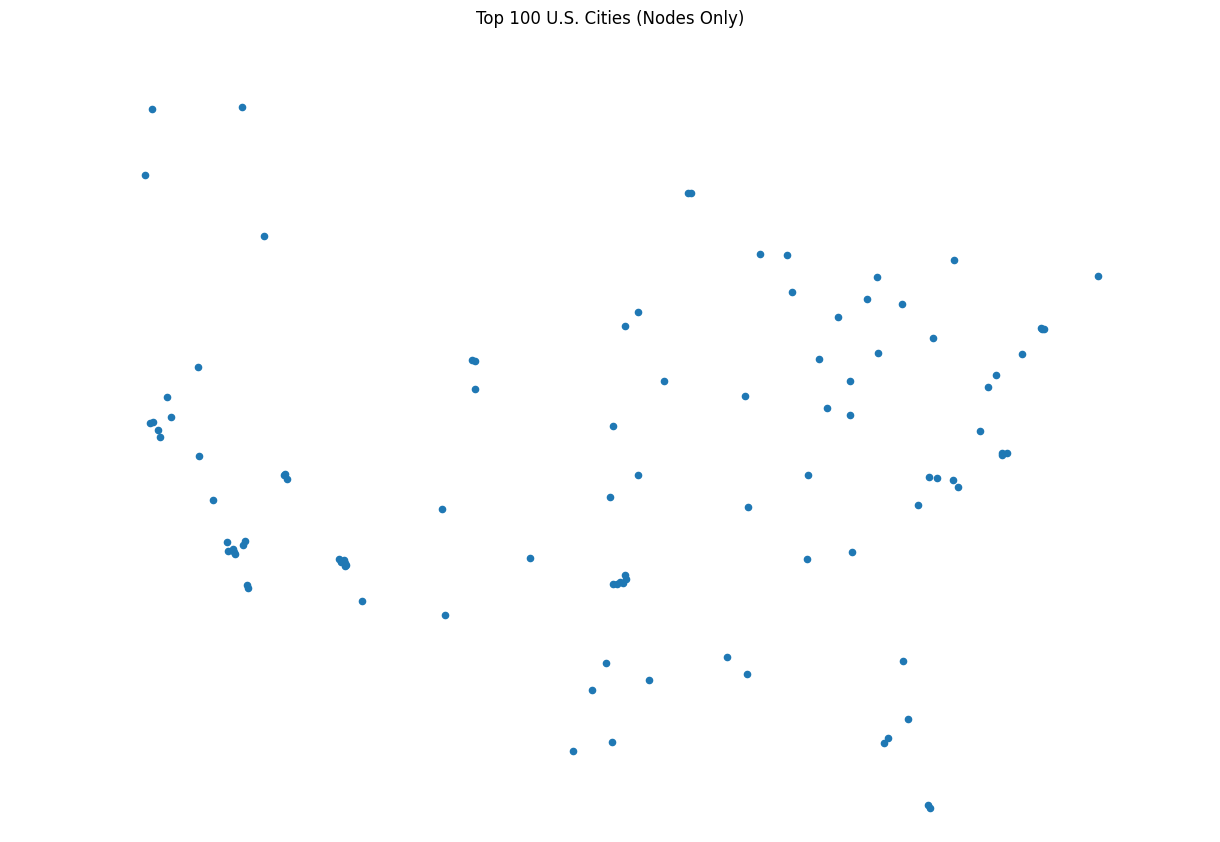

In [5]:
pos_vals = nx.get_node_attributes(top_100_graph, "pos")

plt.figure(figsize=(12,8))

nx.draw(top_100_graph, pos_vals, node_size=20, with_labels=False)

plt.title("Top 100 U.S. Cities (Nodes Only)")
plt.xlim(-130, -65)
plt.ylim(25, 50)

plt.show()

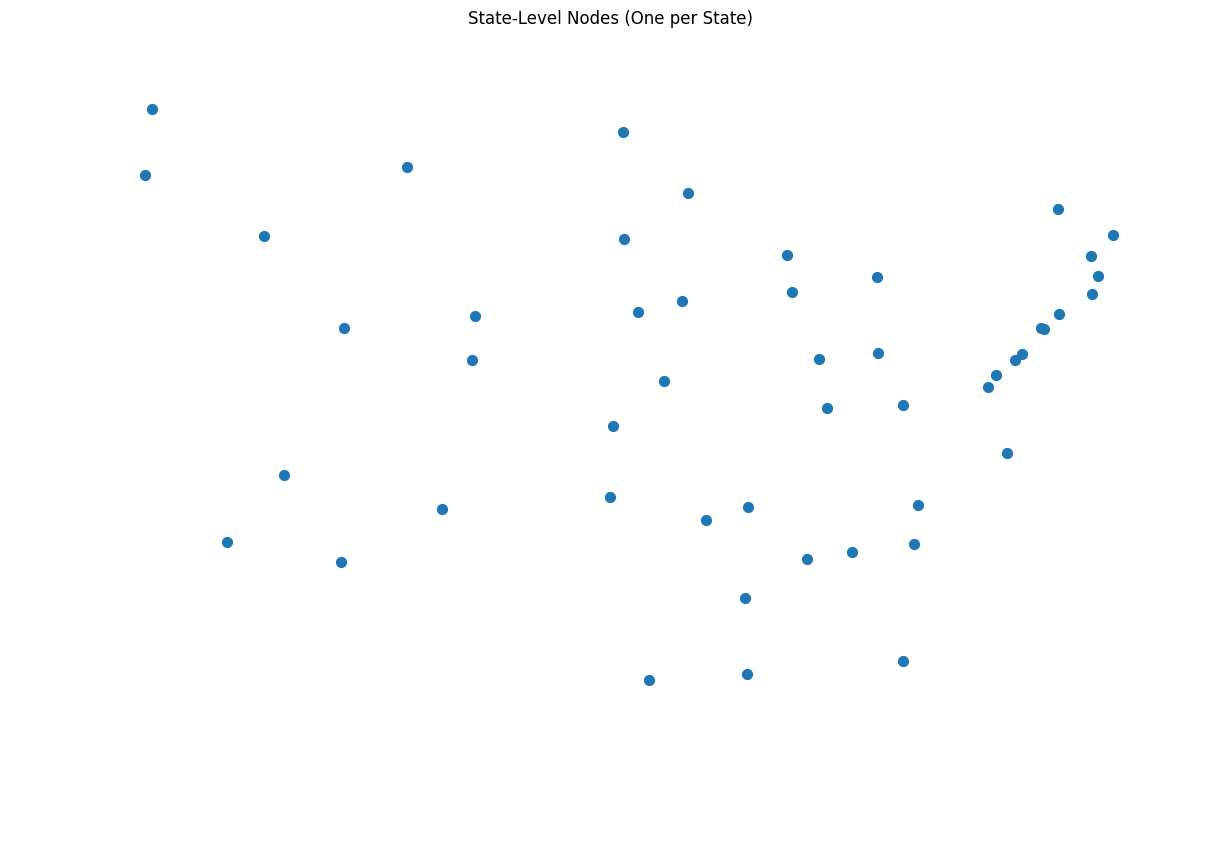

In [6]:
pos_state = nx.get_node_attributes(state_graph, "pos")

plt.figure(figsize=(12,8))

nx.draw(state_graph, pos_state, node_size=50, with_labels=False)

plt.title("State-Level Nodes (One per State)")
plt.xlim(-130, -65)
plt.ylim(25, 50)

plt.show()

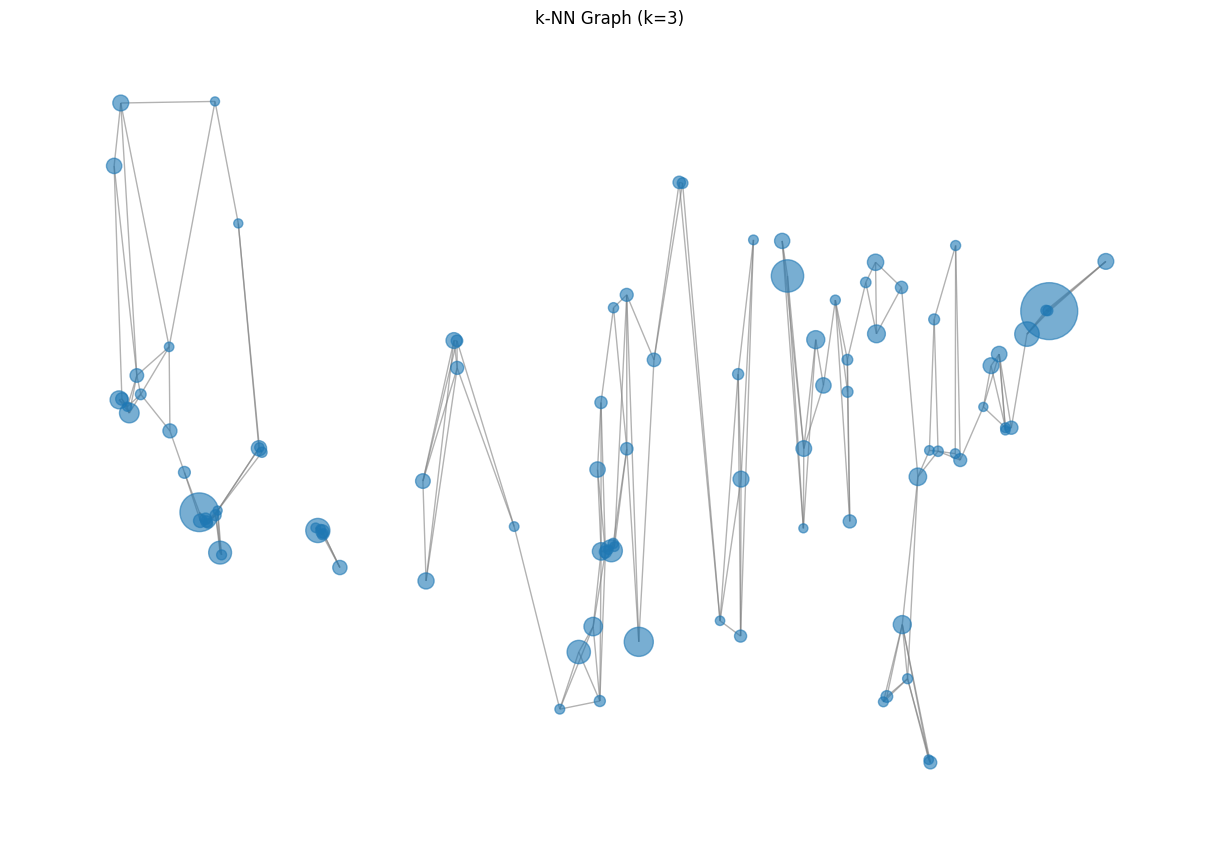

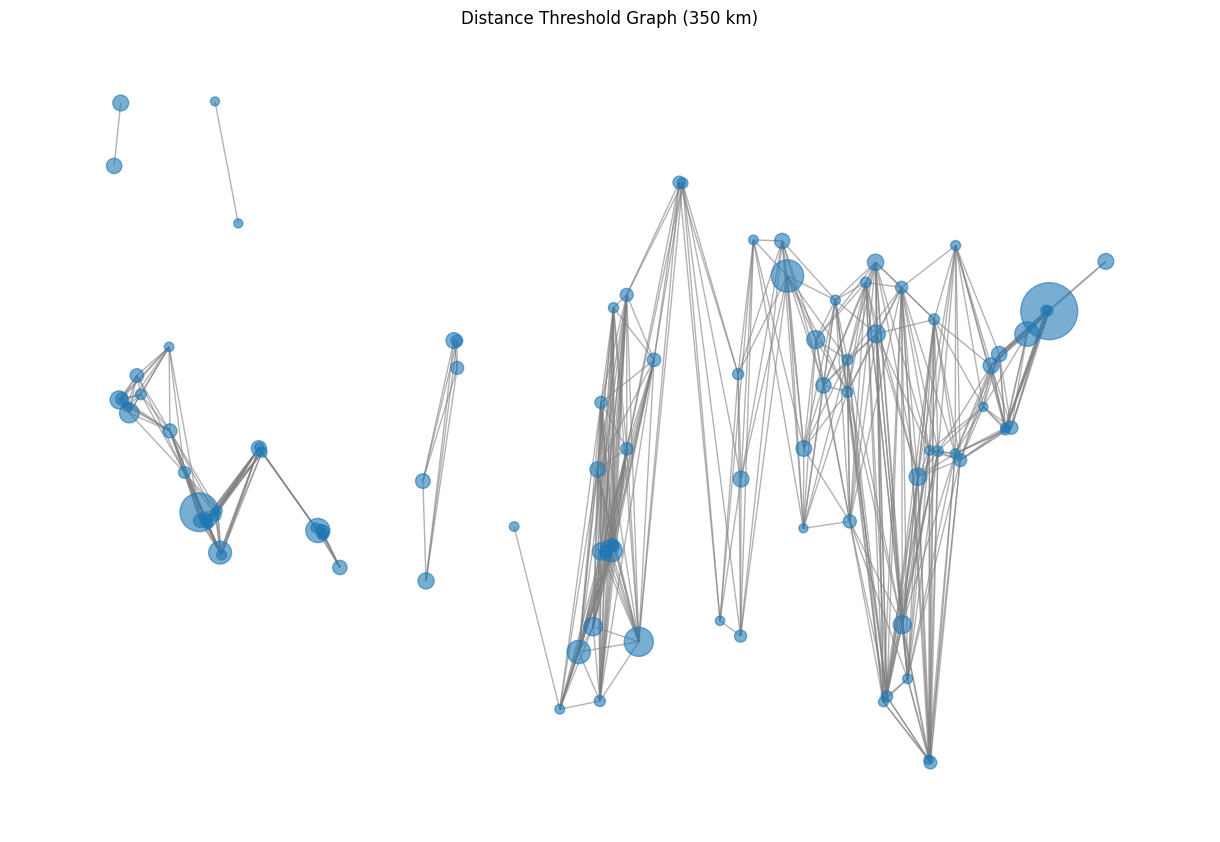

In [7]:
import math
import networkx as nx
import matplotlib.pyplot as plt


def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1 = math.radians(lat1), math.radians(lon1)
    lat2, lon2 = math.radians(lat2), math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


def build_knn_graph(base_graph, k=3):
    G = base_graph.copy()
    nodes = list(G.nodes(data=True))

    for i in range(len(nodes)):
        node1, data1 = nodes[i]
        lat1, lon1 = data1["pos"]

        distances = []

        for j in range(len(nodes)):
            if i != j:
                node2, data2 = nodes[j]
                lat2, lon2 = data2["pos"]

                d = haversine(lat1, lon1, lat2, lon2)
                distances.append((d, node2))

        distances.sort()  # We are sorting based on distance here

        for d, neighbor in distances[:k]:
            G.add_edge(node1, neighbor, weight=d)

    return G


def build_threshold_graph(base_graph, threshold_km):
    G = base_graph.copy()
    nodes = list(G.nodes(data=True))

    for i in range(len(nodes)):
        node1, data1 = nodes[i]
        lat1, lon1 = data1["pos"]

        for j in range(i + 1, len(nodes)):
            node2, data2 = nodes[j]
            lat2, lon2 = data2["pos"]

            d = haversine(lat1, lon1, lat2, lon2)

            if d <= threshold_km:
                G.add_edge(node1, node2, weight=d)

    return G


def draw(G, title):
    pos = nx.get_node_attributes(G, "pos")

    node_sizes = []
    for node in G.nodes():
        if "population" in G.nodes[node]:
            node_sizes.append(G.nodes[node]["population"] / 5000)
        else:
            node_sizes.append(30)

    plt.figure(figsize=(12, 8))

    nx.draw(
        G,
        pos,
        node_size=node_sizes,
        edge_color="gray",
        alpha=0.6,
        with_labels=False
    )

    plt.title(title)
    plt.show()


G_knn = build_knn_graph(top_100_graph, k=3)
G_thresh = build_threshold_graph(top_100_graph, threshold_km=350)

draw(G_knn, "k-NN Graph (k=3)")
draw(G_thresh, "Distance Threshold Graph (350 km)")